# THINGS-EEG2 → captions a partir de las carpetas de conceptos

Notebook reproducible para construir un índice:

**fila EEG ↔ imagen THINGS-EEG2 ↔ concepto ↔ caption de categoría**

No se necesitan captions externos. La carpeta de cada concepto es la fuente semántica y el
caption se calcula **una sola vez por carpeta**, reutilizándolo para todas sus imágenes. Por
ejemplo:

```text
00006_air_mattress/air_mattress_02s.jpg → Air mattress
```

El notebook genera una fila por imagen con:

- split (`train` / `test`) y `row_idx_0based`, alineable con la primera dimensión del EEG;
- ID, carpeta y clave original del concepto;
- nombre, ruta absoluta y ruta relativa de la imagen;
- caption fijo de categoría;
- caption permutado desde **otro concepto** para controles negativos.

## Estructura observada y esperada

```text
THINGS-EEG2/
└── image_set/
    ├── training_images/              # 1 654 carpetas × 10 JPG = 16 540 imágenes
    │   ├── 00001_aardvark/
    │   ├── 00006_air_mattress/
    │   └── ...
    ├── test_images/                  # 200 carpetas × 1 JPG = 200 imágenes
    ├── image_metadata.npy            # índice opcional; no contiene captions
    └── generated_captions/           # salida creada por este notebook
```

`image_metadata.npy` sí está presente en la copia inspeccionada, pero solo contiene listas de
conceptos/ficheros. La extracción de captions **no depende** de él. Cuando existe, se usa como
auditoría adicional para demostrar que `row_idx_0based` conserva exactamente el orden de los
arrays EEG.

> **Alcance semántico:** estos son captions de categoría, no descripciones humanas detalladas
> de cada fotografía. Todas las imágenes de una carpeta reciben el mismo caption. Esto es rápido,
> determinista y evita inventar atributos que el nombre de la clase no garantiza.


## 1. Dependencias

Solo se necesitan librerías habituales del proyecto:

```bash
pip install numpy pandas matplotlib pillow
```


In [1]:
from pathlib import Path
import json
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Imports OK")


Imports OK


## 2. Configuración

`STRIP_TERMINAL_VARIANT_DIGITS=True` convierte claves internas como `bat1` y `bat2` en
el caption natural `Bat`. La clave original siempre se conserva en `concept_key`. Si se conoce
una formulación más precisa para una clase ambigua, se añade a `CAPTION_OVERRIDES`.

`VERIFY_EVERY_IMAGE=False` evita abrir 16 740 ficheros en cada ejecución. Las rutas y los
patrones de nombre se verifican siempre; la integridad binaria completa es opcional.


In [2]:
DATASET_ROOT = Path(r"C:\Users\xxdia\Documents\Datasets\THINGS-EEG2")

IMAGE_SET_ROOT = DATASET_ROOT / "image_set"
TRAIN_ROOT = IMAGE_SET_ROOT / "training_images"
TEST_ROOT = IMAGE_SET_ROOT / "test_images"
METADATA_PATH = IMAGE_SET_ROOT / "image_metadata.npy"
OUTPUT_DIR = IMAGE_SET_ROOT / "generated_captions"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
STRIP_TERMINAL_VARIANT_DIGITS = True
VERIFY_EVERY_IMAGE = False
SAVE_OUTPUTS = True

# Conteos de la versión de THINGS-EEG2 inspeccionada. Si se trabaja con otra
# distribución, se pueden actualizar o poner a None para omitir el chequeo exacto.
EXPECTED_COUNTS = {
    "train": {"concepts": 1654, "images": 16540, "images_per_concept": 10},
    "test": {"concepts": 200, "images": 200, "images_per_concept": 1},
}

# Correcciones explícitas y auditables. Se aplican antes de la normalización automática.
CAPTION_OVERRIDES = {
    "cd_player": "CD player",
}

print("DATASET_ROOT :", DATASET_ROOT)
print("TRAIN_ROOT   :", TRAIN_ROOT)
print("TEST_ROOT    :", TEST_ROOT)
print("METADATA     :", METADATA_PATH)
print("OUTPUT_DIR   :", OUTPUT_DIR)


DATASET_ROOT : C:\Users\xxdia\Documents\Datasets\THINGS-EEG2
TRAIN_ROOT   : C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images
TEST_ROOT    : C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images
METADATA     : C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\image_metadata.npy
OUTPUT_DIR   : C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions


In [3]:
required_directories = {
    "image_set": IMAGE_SET_ROOT,
    "training_images": TRAIN_ROOT,
    "test_images": TEST_ROOT,
}

missing = [f"{name}: {path}" for name, path in required_directories.items() if not path.is_dir()]

if missing:
    raise FileNotFoundError(
        "No se encuentra la estructura necesaria de THINGS-EEG2:\n- "
        + "\n- ".join(missing)
    )

print("✓ Rutas verificadas")


✓ Rutas verificadas


## 3. Reglas de nombres y construcción del caption

Se validan dos convenciones:

```text
carpeta:  00006_air_mattress
          └─ ID ┘└─ concept_key ─┘

fichero:  air_mattress_02s.jpg
          └concepto────┘└┬┘
                         número + código de procedencia
```

El código final (`b`, `n` o `s` en esta copia) se conserva como `source_code`, pero no se
interpreta: no es necesario para formar el caption.


In [4]:
FOLDER_RE = re.compile(r"^(?P<concept_id>\d{5})_(?P<concept_key>.+)$")
IMAGE_RE = re.compile(
    r"^(?P<file_concept>.+)_(?P<image_number>\d{2})"
    r"(?P<source_code>[a-z])\.(?P<extension>jpe?g|png)$",
    re.IGNORECASE,
)
TERMINAL_VARIANT_RE = re.compile(r"(?<=[A-Za-z])\d+$")


def concept_to_caption(
    concept_key: str,
    *,
    strip_terminal_variant_digits: bool = STRIP_TERMINAL_VARIANT_DIGITS,
) -> str:
    """Convierte una clave de carpeta en un caption corto y determinista."""
    concept_key = str(concept_key).strip()

    if not concept_key:
        raise ValueError("concept_key no puede estar vacío")

    if concept_key in CAPTION_OVERRIDES:
        return CAPTION_OVERRIDES[concept_key]

    text = concept_key.replace("_", " ")

    if strip_terminal_variant_digits:
        text = TERMINAL_VARIANT_RE.sub("", text)

    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        raise ValueError(f"No se pudo construir caption para {concept_key!r}")

    # Solo se capitaliza la primera letra: "air mattress" → "Air mattress".
    # Así no convertimos cada palabra en título ni alteramos los guiones.
    return text[:1].upper() + text[1:]


assert concept_to_caption("air_mattress") == "Air mattress"
assert concept_to_caption("first-aid_kit") == "First-aid kit"
assert concept_to_caption("cd_player") == "CD player"

print("Ejemplo:", concept_to_caption("air_mattress"))


Ejemplo: Air mattress


## 4. Descubrir imágenes desde el sistema de ficheros

La carpeta se analiza una vez y su caption se propaga a sus imágenes. El orden es explícito:

1. `concept_id_1based` de la carpeta;
2. número de imagen dentro del concepto;
3. código de procedencia y nombre del fichero como desempate.

Si aparece una carpeta mal formada, un fichero inesperado, un subdirectorio anidado o una
discrepancia entre la clave de la carpeta y la del fichero, el proceso falla en vez de omitir
datos silenciosamente.


In [5]:
def discover_things_images(root: Path, split: str) -> pd.DataFrame:
    """Construye una tabla por imagen usando solo carpetas y nombres de fichero."""
    split = split.lower()

    if split not in {"train", "test"}:
        raise ValueError("split debe ser 'train' o 'test'")

    if not root.is_dir():
        raise FileNotFoundError(root)

    rows = []
    errors = []

    for concept_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        folder_match = FOLDER_RE.fullmatch(concept_dir.name)

        if folder_match is None:
            errors.append(f"Carpeta no reconocida: {concept_dir}")
            continue

        concept_id = int(folder_match.group("concept_id"))
        concept_key = folder_match.group("concept_key")
        caption = concept_to_caption(concept_key)

        nested_dirs = sorted(path.name for path in concept_dir.iterdir() if path.is_dir())
        if nested_dirs:
            errors.append(
                f"{concept_dir.name}: subdirectorios inesperados: {nested_dirs[:5]}"
            )

        files = sorted(path for path in concept_dir.iterdir() if path.is_file())

        if not files:
            errors.append(f"Carpeta sin imágenes: {concept_dir}")
            continue

        for image_path in files:
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                errors.append(f"Extensión inesperada: {image_path}")
                continue

            file_match = IMAGE_RE.fullmatch(image_path.name)

            if file_match is None:
                errors.append(f"Nombre de imagen no reconocido: {image_path}")
                continue

            file_concept = file_match.group("file_concept")

            if file_concept != concept_key:
                errors.append(
                    f"Concepto no coincide: carpeta={concept_key!r}, "
                    f"fichero={file_concept!r}, ruta={image_path}"
                )
                continue

            rows.append({
                "split": split,
                "concept_id_1based": concept_id,
                "concept_folder": concept_dir.name,
                "concept_key": concept_key,
                "caption": caption,
                "primary_caption": caption,
                "caption_source": "concept_folder",
                "image_number_1based": int(file_match.group("image_number")),
                "source_code": file_match.group("source_code").lower(),
                "filename": image_path.name,
                "image_id": image_path.stem,
                "relative_path": image_path.relative_to(IMAGE_SET_ROOT).as_posix(),
                "image_path": str(image_path.resolve()),
            })

    if errors:
        preview = "\n- ".join(errors[:20])
        extra = "" if len(errors) <= 20 else f"\n... y {len(errors) - 20} errores más"
        raise ValueError(f"Errores al descubrir {split}:\n- {preview}{extra}")

    table = pd.DataFrame(rows)

    if table.empty:
        raise RuntimeError(f"No se encontraron imágenes en {root}")

    table = (
        table.sort_values(
            ["concept_id_1based", "image_number_1based", "source_code", "filename"]
        )
        .reset_index(drop=True)
    )
    table.insert(1, "row_idx_0based", np.arange(len(table), dtype=np.int64))
    return table


train_table = discover_things_images(TRAIN_ROOT, "train")
test_table = discover_things_images(TEST_ROOT, "test")

print("Train:", train_table.shape)
print("Test :", test_table.shape)
display(train_table.head(12))
display(test_table.head())


Train: (16540, 14)
Test : (200, 14)


,split,row_idx_0based,concept_id_1based,concept_folder,concept_key,caption,primary_caption,caption_source,image_number_1based,source_code,filename,image_id,relative_path,image_path
0,train,0,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,1,b,aardvark_01b.jpg,aardvark_01b,training_images/00001_aardvark/aardvark_01b.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_01b.jpg
1,train,1,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,2,s,aardvark_02s.jpg,aardvark_02s,training_images/00001_aardvark/aardvark_02s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_02s.jpg
2,train,2,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,3,s,aardvark_03s.jpg,aardvark_03s,training_images/00001_aardvark/aardvark_03s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_03s.jpg
3,train,3,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,4,s,aardvark_04s.jpg,aardvark_04s,training_images/00001_aardvark/aardvark_04s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_04s.jpg
4,train,4,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,5,s,aardvark_05s.jpg,aardvark_05s,training_images/00001_aardvark/aardvark_05s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_05s.jpg
5,train,5,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,6,s,aardvark_06s.jpg,aardvark_06s,training_images/00001_aardvark/aardvark_06s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_06s.jpg
6,train,6,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,7,s,aardvark_07s.jpg,aardvark_07s,training_images/00001_aardvark/aardvark_07s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_07s.jpg
7,train,7,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,8,s,aardvark_08s.jpg,aardvark_08s,training_images/00001_aardvark/aardvark_08s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_08s.jpg
8,train,8,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,9,s,aardvark_09s.jpg,aardvark_09s,training_images/00001_aardvark/aardvark_09s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_09s.jpg
9,train,9,1,00001_aardvark,aardvark,Aardvark,Aardvark,concept_folder,10,s,aardvark_10s.jpg,aardvark_10s,training_images/00001_aardvark/aardvark_10s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\training_images\00001_aardvark\aardvark_10s.jpg


,split,row_idx_0based,concept_id_1based,concept_folder,concept_key,caption,primary_caption,caption_source,image_number_1based,source_code,filename,image_id,relative_path,image_path
0,test,0,1,00001_aircraft_carrier,aircraft_carrier,Aircraft carrier,Aircraft carrier,concept_folder,6,s,aircraft_carrier_06s.jpg,aircraft_carrier_06s,test_images/00001_aircraft_carrier/aircraft_carrier_06s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images\00001_aircraft_carrier\aircraft_carrier_06s.jpg
1,test,1,2,00002_antelope,antelope,Antelope,Antelope,concept_folder,1,b,antelope_01b.jpg,antelope_01b,test_images/00002_antelope/antelope_01b.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images\00002_antelope\antelope_01b.jpg
2,test,2,3,00003_backscratcher,backscratcher,Backscratcher,Backscratcher,concept_folder,1,b,backscratcher_01b.jpg,backscratcher_01b,test_images/00003_backscratcher/backscratcher_01b.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images\00003_backscratcher\backscratcher_01b.jpg
3,test,3,4,00004_balance_beam,balance_beam,Balance beam,Balance beam,concept_folder,4,s,balance_beam_04s.jpg,balance_beam_04s,test_images/00004_balance_beam/balance_beam_04s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images\00004_balance_beam\balance_beam_04s.jpg
4,test,4,5,00005_banana,banana,Banana,Banana,concept_folder,9,s,banana_09s.jpg,banana_09s,test_images/00005_banana/banana_09s.jpg,C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\test_images\00005_banana\banana_09s.jpg


## 5. Validación estructural y cobertura

Además de los conteos del release inspeccionado, se comprueba que:

- los IDs de conceptos son contiguos y empiezan en 1 en cada split;
- no hay rutas ni IDs de imagen duplicados;
- todas las imágenes de un concepto reciben el mismo caption;
- train y test no comparten `concept_key`;
- `row_idx_0based` es contiguo y conserva el orden de la tabla.


In [6]:
def validate_split_table(
    table: pd.DataFrame,
    split: str,
    expected: dict | None = None,
) -> dict:
    if table.empty:
        raise ValueError(f"{split}: tabla vacía")

    if not np.array_equal(table["row_idx_0based"].to_numpy(), np.arange(len(table))):
        raise ValueError(f"{split}: row_idx_0based no es contiguo")

    for column in ["relative_path", "image_path", "image_id"]:
        duplicated = int(table[column].duplicated().sum())
        if duplicated:
            raise ValueError(f"{split}: {duplicated} duplicados en {column}")

    concept_ids = (
        table[["concept_id_1based", "concept_key"]]
        .drop_duplicates()
        .sort_values("concept_id_1based")["concept_id_1based"]
        .to_numpy()
    )
    expected_ids = np.arange(1, len(concept_ids) + 1)

    if not np.array_equal(concept_ids, expected_ids):
        raise ValueError(f"{split}: IDs de concepto no contiguos")

    caption_counts = table.groupby("concept_key")["primary_caption"].nunique()
    if not (caption_counts == 1).all():
        raise ValueError(f"{split}: un concepto tiene más de un caption")

    images_per_concept = table.groupby("concept_key").size()
    n_concepts = int(table["concept_key"].nunique())

    if expected is not None:
        observed = {
            "concepts": n_concepts,
            "images": len(table),
        }
        for key, value in observed.items():
            if value != expected[key]:
                raise ValueError(
                    f"{split}: {key}={value}; se esperaban {expected[key]}"
                )

        expected_per_concept = expected["images_per_concept"]
        if not (images_per_concept == expected_per_concept).all():
            bad = images_per_concept[images_per_concept != expected_per_concept]
            raise ValueError(
                f"{split}: nº inesperado de imágenes por concepto:\n{bad.head(20)}"
            )

    return {
        "split": split,
        "n_images": len(table),
        "n_concepts": n_concepts,
        "min_images_per_concept": int(images_per_concept.min()),
        "max_images_per_concept": int(images_per_concept.max()),
        "n_unique_captions": int(table["primary_caption"].nunique()),
    }


validation_summary = pd.DataFrame([
    validate_split_table(train_table, "train", EXPECTED_COUNTS.get("train")),
    validate_split_table(test_table, "test", EXPECTED_COUNTS.get("test")),
])

concept_overlap = sorted(set(train_table["concept_key"]) & set(test_table["concept_key"]))
if concept_overlap:
    raise ValueError(f"Train/test comparten conceptos: {concept_overlap[:20]}")

display(validation_summary)

print("Distribución de imágenes por concepto (train):")
display(train_table.groupby("concept_key").size().value_counts().sort_index())

print("Distribución de imágenes por concepto (test):")
display(test_table.groupby("concept_key").size().value_counts().sort_index())

print("Códigos finales de fichero:")
display(
    pd.concat([train_table, test_table], ignore_index=True)
    .groupby(["split", "source_code"])
    .size()
    .rename("n_images")
    .reset_index()
)

print("✓ Estructura y cobertura verificadas; train/test son conceptualmente disjuntos")


,split,n_images,n_concepts,min_images_per_concept,max_images_per_concept,n_unique_captions
0,train,16540,1654,10,10,1627
1,test,200,200,1,1,200


Distribución de imágenes por concepto (train):


10    1654
Name: count, dtype: int64

Distribución de imágenes por concepto (test):


1    200
Name: count, dtype: int64

Códigos finales de fichero:


,split,source_code,n_images
0,test,b,35
1,test,n,10
2,test,s,155
3,train,b,1476
4,train,n,534
5,train,s,14530


✓ Estructura y cobertura verificadas; train/test son conceptualmente disjuntos


## 6. Auditoría opcional contra `image_metadata.npy`

El `.npy` no aporta texto descriptivo, pero sí el orden oficial de imágenes. La fila `i` del
EEG preprocesado corresponde a `train_img_files[i]` o `test_img_files[i]`. Esta celda exige
coincidencia exacta, posición por posición, entre el índice descubierto y esas listas.

Si el fichero no existe, la extracción de captions continúa y se emite un aviso. En ese caso,
`row_idx_0based` conserva el orden determinista del filesystem, pero no debe asumirse su
alineación con un array EEG externo sin una comprobación adicional.


In [7]:
def validate_against_image_metadata(
    table: pd.DataFrame,
    metadata: dict,
    split: str,
) -> dict:
    prefix = "train" if split == "train" else "test"
    files_key = f"{prefix}_img_files"
    concepts_key = f"{prefix}_img_concepts"

    missing_keys = [key for key in [files_key, concepts_key] if key not in metadata]
    if missing_keys:
        raise KeyError(f"Metadata sin claves necesarias: {missing_keys}")

    metadata_files = [str(value) for value in metadata[files_key]]
    metadata_concepts = [str(value) for value in metadata[concepts_key]]
    discovered_files = table["filename"].astype(str).tolist()
    discovered_concepts = table["concept_folder"].astype(str).tolist()

    if len(metadata_files) != len(table) or len(metadata_concepts) != len(table):
        raise ValueError(
            f"{split}: longitudes metadata/tabla distintas: "
            f"files={len(metadata_files)}, concepts={len(metadata_concepts)}, table={len(table)}"
        )

    file_mismatches = [
        index for index, (left, right) in enumerate(zip(metadata_files, discovered_files))
        if left != right
    ]
    concept_mismatches = [
        index
        for index, (left, right) in enumerate(zip(metadata_concepts, discovered_concepts))
        if left != right
    ]

    if file_mismatches or concept_mismatches:
        first = min(file_mismatches + concept_mismatches)
        raise ValueError(
            f"{split}: el orden no coincide desde la fila {first}. "
            f"metadata=({metadata_concepts[first]}, {metadata_files[first]}), "
            f"descubierto=({discovered_concepts[first]}, {discovered_files[first]})"
        )

    return {
        "split": split,
        "metadata_rows": len(metadata_files),
        "file_mismatches": 0,
        "concept_mismatches": 0,
        "eeg_row_alignment_verified": True,
    }


metadata_alignment_verified = False
metadata_audit = pd.DataFrame()

if METADATA_PATH.exists():
    image_metadata = np.load(METADATA_PATH, allow_pickle=True).item()

    if not isinstance(image_metadata, dict):
        raise TypeError(f"Formato inesperado en {METADATA_PATH}: {type(image_metadata)}")

    metadata_audit = pd.DataFrame([
        validate_against_image_metadata(train_table, image_metadata, "train"),
        validate_against_image_metadata(test_table, image_metadata, "test"),
    ])
    metadata_alignment_verified = bool(
        metadata_audit["eeg_row_alignment_verified"].all()
    )
    display(metadata_audit)
    print("✓ row_idx_0based coincide exactamente con el orden oficial EEG↔imagen")
else:
    warnings.warn(
        f"No existe {METADATA_PATH}. Los captions son válidos, pero no se ha auditado "
        "el orden respecto a los arrays EEG."
    )


,split,metadata_rows,file_mismatches,concept_mismatches,eeg_row_alignment_verified
0,train,16540,0,0,True
1,test,200,0,0,True


✓ row_idx_0based coincide exactamente con el orden oficial EEG↔imagen


## 7. Diagnóstico de calidad de las etiquetas

Los guiones se conservan (`first-aid_kit` → `First-aid kit`). Algunas claves llevan un dígito
terminal para distinguir sentidos del inventario THINGS (`bat1`, `bat2`, `baton1`, ...).
Por defecto se elimina ese marcador interno del caption, pero no de `concept_key`.

La tabla de colisiones muestra captions que representan varias claves. No es un error: indica
dónde el nombre de carpeta no basta para desambiguar el sentido. Si se requiere más precisión,
se revisan esas clases visualmente y se añaden formulaciones explícitas a
`CAPTION_OVERRIDES`; no conviene inferirlas automáticamente sin evidencia.


In [8]:
all_tables = pd.concat([train_table, test_table], ignore_index=True)
concept_table = (
    all_tables[
        ["split", "concept_id_1based", "concept_folder", "concept_key", "primary_caption"]
    ]
    .drop_duplicates()
    .sort_values(["split", "concept_id_1based"])
    .reset_index(drop=True)
)

numbered_concepts = concept_table[
    concept_table["concept_key"].str.contains(r"\d+$", regex=True)
]
hyphenated_concepts = concept_table[
    concept_table["concept_key"].str.contains("-", regex=False)
]
caption_collisions = (
    concept_table.groupby(["split", "primary_caption"])
    .agg(
        n_concept_keys=("concept_key", "nunique"),
        concept_keys=("concept_key", lambda values: sorted(values.tolist())),
    )
    .reset_index()
)
caption_collisions = caption_collisions[caption_collisions["n_concept_keys"] > 1]

air_mattress = concept_table.loc[
    concept_table["concept_key"] == "air_mattress",
    ["concept_folder", "concept_key", "primary_caption"],
]
if air_mattress.empty or air_mattress.iloc[0]["primary_caption"] != "Air mattress":
    raise AssertionError("El ejemplo air_mattress no produce el caption esperado")

print("Ejemplo solicitado:")
display(air_mattress)

print(f"Conceptos con marcador numérico terminal: {len(numbered_concepts)}")
display(numbered_concepts)

print(f"Conceptos con guion conservado: {len(hyphenated_concepts)}")
display(hyphenated_concepts)

print(f"Captions compartidos por varias concept_key: {len(caption_collisions)}")
display(caption_collisions)


Ejemplo solicitado:


,concept_folder,concept_key,primary_caption
205,00006_air_mattress,air_mattress,Air mattress


Conceptos con marcador numérico terminal: 58


,split,concept_id_1based,concept_folder,concept_key,primary_caption
9,test,10,00010_baton4,baton4,Baton
39,test,40,00040_chest2,chest2,Chest
131,test,132,00132_pepper1,pepper1,Pepper
144,test,145,00145_punch2,punch2,Punch
278,train,79,00079_bat1,bat1,Bat
279,train,80,00080_bat2,bat2,Bat
283,train,84,00084_baton1,baton1,Baton
284,train,85,00085_baton2,baton2,Baton
285,train,86,00086_baton3,baton3,Baton
354,train,155,00155_bow1,bow1,Bow


Conceptos con guion conservado: 9


,split,concept_id_1based,concept_folder,concept_key,primary_caption
176,test,177,00177_t-shirt,t-shirt,T-shirt
724,train,525,00525_first-aid_kit,first-aid_kit,First-aid kit
799,train,600,00600_go-kart,go-kart,Go-kart
905,train,706,00706_hot-air_balloon,hot-air_balloon,Hot-air balloon
906,train,707,00707_hot-water_bottle,hot-water_bottle,Hot-water bottle
920,train,721,00721_ice-cream_cone,ice-cream_cone,Ice-cream cone
1247,train,1048,01048_ping-pong_table,ping-pong_table,Ping-pong table
1279,train,1080,01080_pom-pom,pom-pom,Pom-pom
1847,train,1648,01648_yo-yo,yo-yo,Yo-yo


Captions compartidos por varias concept_key: 24


,split,primary_caption,n_concept_keys,concept_keys
278,train,Bat,2,"[bat1, bat2]"
282,train,Baton,3,"[baton1, baton2, baton3]"
351,train,Bow,3,"[bow1, bow2, bow3]"
361,train,Bracelet,2,"[bracelet1, bracelet2]"
396,train,Button,2,"[button1, button2]"
405,train,Calf,2,"[calf1, calf2]"
409,train,Camera,2,"[camera1, camera2]"
473,train,Chicken,2,"[chicken1, chicken2]"
502,train,Clipper,2,"[clipper1, clipper2]"
582,train,Crystal,2,"[crystal1, crystal2]"


## 8. Inspección visual

Se muestrea como máximo una imagen por concepto para no revisar varias veces la misma etiqueta.
Esta inspección es especialmente útil después de añadir `CAPTION_OVERRIDES`.


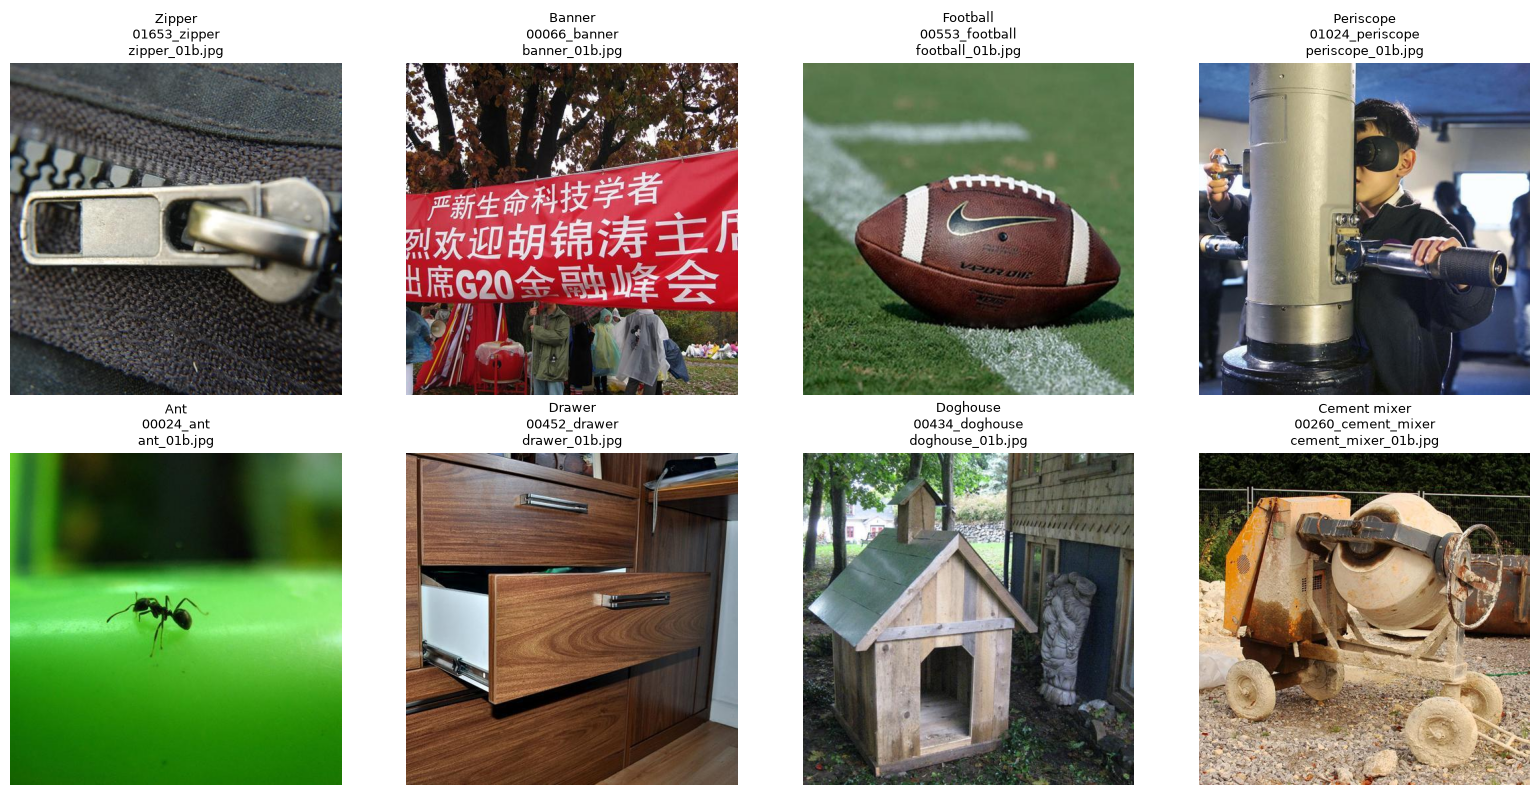

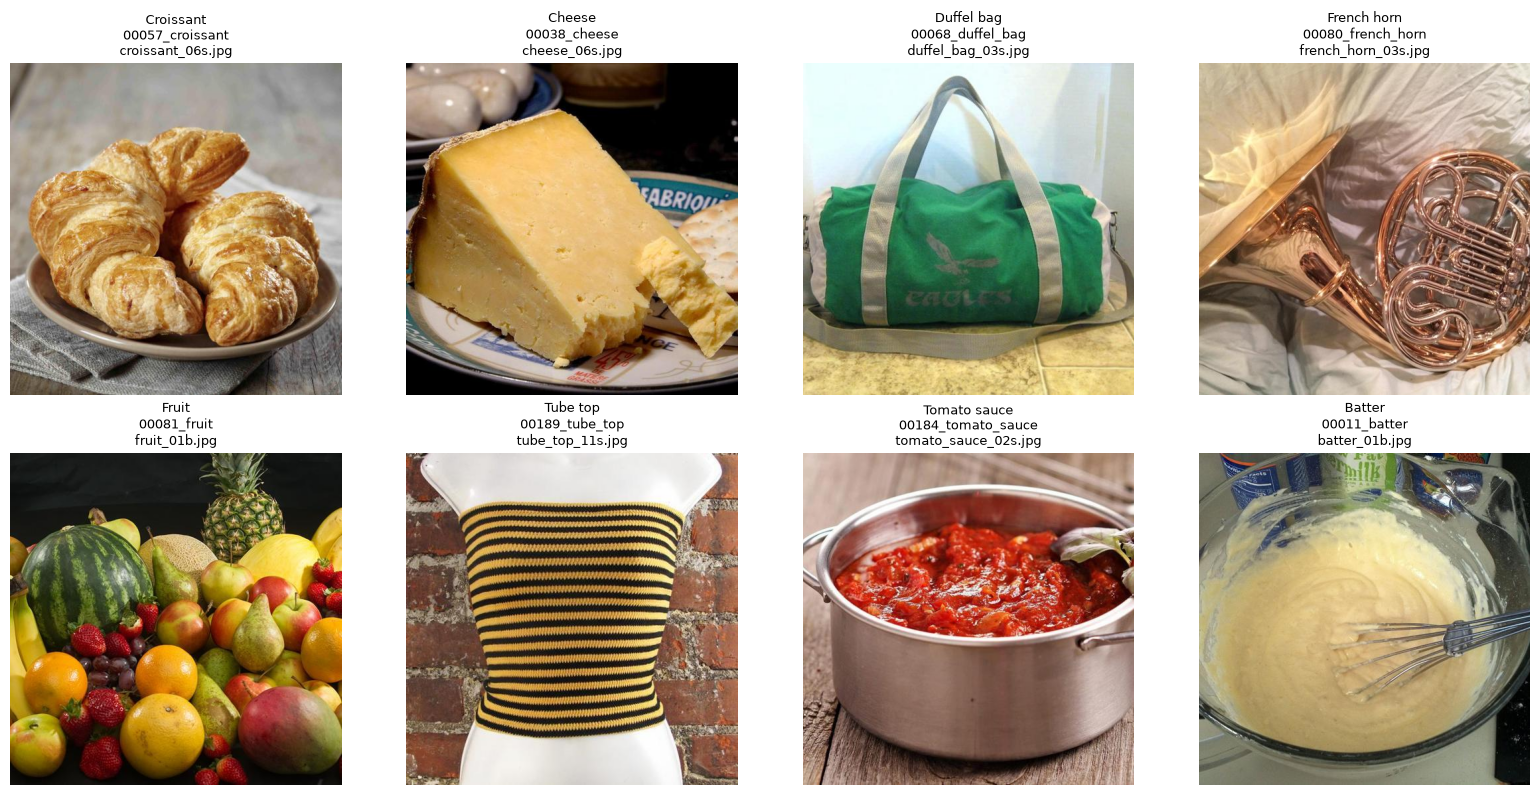

In [9]:
def show_samples(table: pd.DataFrame, n: int = 8, seed: int = SEED) -> None:
    if table.empty:
        print("Tabla vacía")
        return

    candidates = table.drop_duplicates("concept_key")
    sample = candidates.sample(n=min(n, len(candidates)), random_state=seed)
    ncols = 4
    nrows = int(np.ceil(len(sample) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for axis, (_, row) in zip(axes, sample.iterrows()):
        with Image.open(row["image_path"]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(
            f'{row["primary_caption"]}\n{row["concept_folder"]}\n{row["filename"]}',
            fontsize=9,
        )
        axis.axis("off")

    for axis in axes[len(sample):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_table, n=8, seed=SEED)
show_samples(test_table, n=8, seed=SEED + 1)


## 9. Verificación binaria opcional de todos los JPG

El escaneo anterior valida existencia, extensión y nombres. Activar esta celda abre y verifica
cada imagen con Pillow; es más lento y normalmente solo hace falta una vez tras descargar o
descomprimir el dataset.


In [10]:
def verify_image_files(table: pd.DataFrame) -> pd.DataFrame:
    errors = []

    for row in table.itertuples(index=False):
        try:
            with Image.open(row.image_path) as image:
                image.verify()
        except Exception as exc:
            errors.append({
                "split": row.split,
                "row_idx_0based": row.row_idx_0based,
                "image_path": row.image_path,
                "error": repr(exc),
            })

    return pd.DataFrame(errors)


if VERIFY_EVERY_IMAGE:
    image_errors = verify_image_files(all_tables)
    if not image_errors.empty:
        display(image_errors.head(20))
        raise ValueError(f"Hay {len(image_errors)} imágenes dañadas o ilegibles")
    print(f"✓ {len(all_tables):,} imágenes verificadas con Pillow")
else:
    print("Verificación binaria omitida (VERIFY_EVERY_IMAGE=False)")


Verificación binaria omitida (VERIFY_EVERY_IMAGE=False)


## 10. Caption permutado por concepto

Un permutado ingenuo por imagen podría asignar otra foto de la **misma carpeta**, que no sería
un control negativo real. Aquí se permutan primero los conceptos y luego se propaga la asignación
a todas sus imágenes. Se exige que cambien tanto `concept_key` como el texto del caption.


In [11]:
def add_permuted_concept_caption(
    table: pd.DataFrame,
    seed: int = SEED,
) -> pd.DataFrame:
    out = table.copy()
    caption_col = f"permuted_caption_seed{seed}"
    source_col = f"permuted_from_concept_key_seed{seed}"

    concepts = (
        out[["concept_key", "primary_caption"]]
        .drop_duplicates()
        .sort_values("concept_key")
        .reset_index(drop=True)
    )

    if len(concepts) < 2:
        raise ValueError("Se necesitan al menos dos conceptos para crear el control")

    rng = np.random.default_rng(seed)
    original_keys = concepts["concept_key"].to_numpy()
    original_captions = concepts["primary_caption"].to_numpy()
    permutation = None

    for _ in range(10000):
        candidate = rng.permutation(len(concepts))
        if (
            np.all(original_keys[candidate] != original_keys)
            and np.all(original_captions[candidate] != original_captions)
        ):
            permutation = candidate
            break

    if permutation is None:
        raise RuntimeError("No se pudo construir una permutación válida")

    permuted = concepts.iloc[permutation].reset_index(drop=True)
    caption_map = dict(zip(original_keys, permuted["primary_caption"]))
    source_map = dict(zip(original_keys, permuted["concept_key"]))

    out[caption_col] = out["concept_key"].map(caption_map)
    out[source_col] = out["concept_key"].map(source_map)

    if (out[caption_col] == out["primary_caption"]).any():
        raise AssertionError("El control contiene captions sin cambiar")
    if (out[source_col] == out["concept_key"]).any():
        raise AssertionError("El control contiene conceptos sin cambiar")

    return out


train_table = add_permuted_concept_caption(train_table, SEED)
test_table = add_permuted_concept_caption(test_table, SEED)
combined_table = pd.concat([train_table, test_table], ignore_index=True)

display(
    combined_table[
        [
            "split",
            "filename",
            "concept_key",
            "primary_caption",
            f"permuted_from_concept_key_seed{SEED}",
            f"permuted_caption_seed{SEED}",
        ]
    ].sample(10, random_state=SEED)
)


,split,filename,concept_key,primary_caption,permuted_from_concept_key_seed42,permuted_caption_seed42
8046,train,leggings_07s.jpg,leggings,Leggings,float,Float
1208,train,blackberry_09n.jpg,blackberry,Blackberry,knot,Knot
3826,train,crayon_07s.jpg,crayon,Crayon,photograph,Photograph
99,train,airplane_10n.jpg,airplane,Airplane,shuffleboard,Shuffleboard
14285,train,syringe_06s.jpg,syringe,Syringe,shoehorn,Shoehorn
10612,train,platypus_03s.jpg,platypus,Platypus,record,Record
1087,train,berry_08s.jpg,berry,Berry,llama,Llama
7581,train,kale_02s.jpg,kale,Kale,stopwatch,Stopwatch
15589,train,urn_10s.jpg,urn,Urn,hotplate,Hotplate
12751,train,shrimp_02s.jpg,shrimp,Shrimp,corkscrew,Corkscrew


## 11. Guardar CSV y JSON

Se crean tablas por imagen y una tabla compacta por concepto:

```text
generated_captions/
├── thingseeg2_training_image_captions.csv
├── thingseeg2_training_image_captions.json
├── thingseeg2_test_image_captions.csv
├── thingseeg2_test_image_captions.json
├── thingseeg2_all_image_captions.csv
├── thingseeg2_all_image_captions.json
├── thingseeg2_concept_captions.csv
├── thingseeg2_concept_captions.json
├── caption_mapping_summary.csv
└── caption_mapping_summary.json
```

No se crean copias por sujeto: las imágenes y su orden son comunes a todos los sujetos de
THINGS-EEG2, por lo que una sola tabla sirve para `sub-01` ... `sub-10`.


In [12]:
def json_safe_value(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, float) and np.isnan(value):
        return None
    if pd.isna(value):
        return None
    return value


def records_for_json(table: pd.DataFrame) -> list[dict]:
    return [
        {key: json_safe_value(value) for key, value in row.items()}
        for row in table.to_dict(orient="records")
    ]


def save_table(table: pd.DataFrame, stem: str) -> list[Path]:
    csv_path = OUTPUT_DIR / f"{stem}.csv"
    json_path = OUTPUT_DIR / f"{stem}.json"

    table.to_csv(csv_path, index=False, encoding="utf-8")
    with json_path.open("w", encoding="utf-8") as file:
        json.dump(
            records_for_json(table),
            file,
            ensure_ascii=False,
            indent=2,
        )

    return [csv_path, json_path]


concept_output = (
    combined_table[
        [
            "split",
            "concept_id_1based",
            "concept_folder",
            "concept_key",
            "primary_caption",
            "caption_source",
            f"permuted_from_concept_key_seed{SEED}",
            f"permuted_caption_seed{SEED}",
        ]
    ]
    .drop_duplicates()
    .sort_values(["split", "concept_id_1based"])
    .reset_index(drop=True)
)

mapping_summary = (
    combined_table.groupby("split")
    .agg(
        n_images=("filename", "size"),
        n_concepts=("concept_key", "nunique"),
        n_unique_captions=("primary_caption", "nunique"),
        missing_captions=("primary_caption", lambda values: int(values.isna().sum())),
        min_images_per_concept=("concept_key", lambda values: int(values.value_counts().min())),
        max_images_per_concept=("concept_key", lambda values: int(values.value_counts().max())),
    )
    .reset_index()
)
mapping_summary["metadata_order_verified"] = metadata_alignment_verified

saved = []

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    saved += save_table(train_table, "thingseeg2_training_image_captions")
    saved += save_table(test_table, "thingseeg2_test_image_captions")
    saved += save_table(combined_table, "thingseeg2_all_image_captions")
    saved += save_table(concept_output, "thingseeg2_concept_captions")
    saved += save_table(mapping_summary, "caption_mapping_summary")

    print("Archivos creados:")
    for path in saved:
        print(" -", path)
else:
    print("Guardado omitido (SAVE_OUTPUTS=False)")

display(mapping_summary)


Archivos creados:
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_training_image_captions.csv
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_training_image_captions.json
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_test_image_captions.csv
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_test_image_captions.json
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_all_image_captions.csv
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_all_image_captions.json
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_concept_captions.csv
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_captions\thingseeg2_concept_captions.json
 - C:\Users\xxdia\Documents\Datasets\THINGS-EEG2\image_set\generated_capti

,split,n_images,n_concepts,n_unique_captions,missing_captions,min_images_per_concept,max_images_per_concept,metadata_order_verified
0,test,200,200,200,0,1,1,True
1,train,16540,1654,1627,0,10,10,True


## 12. Comprobación de lectura y alineación por índice

Para cualquier sujeto, `row_idx_0based=i` se usa con la fila `i` del array EEG del mismo
split. Esta garantía queda demostrada si `metadata_order_verified=True` en el resumen.


In [13]:
def build_caption_lookup(table: pd.DataFrame) -> dict[tuple[str, int], str]:
    if table.duplicated(["split", "row_idx_0based"]).any():
        raise ValueError("Hay claves (split, row_idx_0based) duplicadas")

    return {
        (row.split, int(row.row_idx_0based)): row.primary_caption
        for row in table.itertuples(index=False)
    }


caption_lookup = build_caption_lookup(combined_table)

example_train_index = int(
    train_table.loc[train_table["filename"] == "air_mattress_02s.jpg", "row_idx_0based"].iloc[0]
)

print("Ejemplo de acceso:")
print(" split             : train")
print(" EEG/image row     :", example_train_index)
print(" caption           :", caption_lookup[("train", example_train_index)])

if caption_lookup[("train", example_train_index)] != "Air mattress":
    raise AssertionError("Lookup desalineado para air_mattress_02s.jpg")


Ejemplo de acceso:
 split             : train
 EEG/image row     : 51
 caption           : Air mattress


## 13. Integración opcional con PyTorch

El índice se puede cargar una vez y consultar con el índice de imagen usado por el dataset EEG:

```python
captions = (
    pd.read_csv(
        r"C:\Users\xxdia\Documents\Datasets\THINGS-EEG2"
        r"\image_set\generated_captions\thingseeg2_all_image_captions.csv"
    )
    .set_index(["split", "row_idx_0based"])
)

# img_index es el índice de la primera dimensión de preprocessed_eeg_data.
row = captions.loc[(source, img_index)]
sample = {
    "eeg": eeg_array[img_index],
    "image_path": row["image_path"],
    "caption": row["primary_caption"],
    "permuted_caption": row["permuted_caption_seed42"],
}
```

Si se usa `src.data.eeg_things_dataset.EegSubjectData`, su `img_index` sigue precisamente el
orden de `image_metadata.npy`; por eso la auditoría de la sección 6 es la comprobación crítica.


# 14. Condiciones experimentales sugeridas

| Experimento | EEG | Texto |
|---|---:|---:|
| `eeg_only` | real | vacío |
| `caption_only_category` | cero/ausente | `primary_caption` |
| `eeg_plus_category` | real | `primary_caption` |
| `eeg_plus_permuted_category` | real | `permuted_caption_seed42` |

Interpretación:

- `eeg_only` conserva el baseline brain-only.
- `caption_only_category` mide cuánto puede generar el modelo con solo la categoría objetivo.
- `eeg_plus_category` combina EEG con esa señal semántica de alto nivel.
- `eeg_plus_permuted_category` comprueba si importa que texto y EEG correspondan al mismo
  concepto.

## Nota metodológica

Aunque el texto sea corto, la categoría se deriva de la carpeta de la imagen objetivo y por
tanto es información *oracle*. No debe presentarse como reconstrucción puramente cerebral.
Tampoco debe describirse como un caption humano: es una etiqueta de clase humanizada. Esta
distinción es importante al comparar resultados y documentarlos en el TFM.

## Resultado principal

El archivo:

```text
.../THINGS-EEG2/image_set/generated_captions/thingseeg2_all_image_captions.csv
```

deja explícita la correspondencia:

```text
fila EEG → imagen → carpeta/concepto → caption de categoría
```
